# 7.3. 강체 회전자

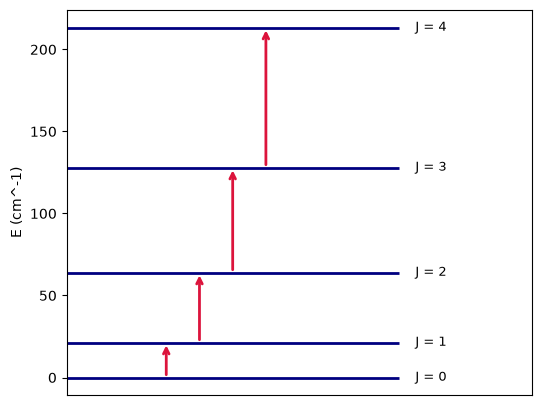

HCl의 회전 상수 = 10.67 cm^-1
J = 0 -> 1: ΔE = 21.34 cm^-1
J = 1 -> 2: ΔE = 42.67 cm^-1
J = 2 -> 3: ΔE = 64.01 cm^-1
J = 3 -> 4: ΔE = 85.34 cm^-1


In [1]:
import matplotlib.pyplot as plt
from scipy.constants import hbar, u, h, c

mu = (1.008 * 34.969) / (1.008 + 34.969) * u
r = 1.27e-10
B = hbar**2 / (2 * mu * r**2) / (100 * h * c)

fig, ax = plt.subplots(figsize=(6, 5))
for J in range(5):
    E = B * J * (J + 1)
    ax.hlines(E, 0, 1, lw=2, color="navy")
    ax.text(1.05, E, f"J = {J}", va="center", fontsize=9)
    ax.annotate(
        "",
        xy=(0.3 + 0.1 * J, B * (J + 1) * (J + 2)),
        xytext=(0.3 + 0.1 * J, E),
        arrowprops=dict(arrowstyle="->", color="crimson", lw=2),
    )

ax.set_xlim(0, 1.4)
ax.set_xticks([])
ax.set_ylabel("E (cm^-1)")
plt.show()

print(f"HCl의 회전 상수 = {B:.2f} cm^-1")

for J in range(4):
    Delta_E = 2 * B * (J + 1)
    print(f"J = {J} -> {J+1}: ΔE = {Delta_E:.2f} cm^-1")

In [2]:
import numpy as np


def bond_length(B_cm, m1, m2):
    mu = m1 * m2 / (m1 + m2) * u
    I = hbar**2 / (2 * B_cm * 100 * h * c)
    return np.sqrt(I / mu) * 1e12


data = [
    ("HF", 20.96, 1.008, 18.998, 91.68),
    ("CO", 1.931, 12.000, 15.995, 112.83),
    ("N2", 1.998, 14.003, 14.003, 109.77),
]

print(f"{'분자':>2} {'B (cm^-1)':>10} {'계산 r':>9} {'실제 r':>9}")
for name, B_cm, m1, m2, r_lit in data:
    print(f"{name:>3} {B_cm:10.3f} {bond_length(B_cm, m1, m2):8.2f} pm {r_lit:7.2f} pm")

분자  B (cm^-1)      계산 r      실제 r
 HF     20.960    91.66 pm   91.68 pm
 CO      1.931   112.84 pm  112.83 pm
 N2      1.998   109.78 pm  109.77 pm
